In [7]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from typing import List


### Structure d'un groupe

```python
group: {
  values: [0, 1, 2, 0, 0, 0, 4, 1, 1],
  cases: [
    {
      id: 1,
      value: 6
    },
    {
      id: 14,
      value: 2
    }
  ]
}
```

## Définition des énergies

In [2]:
## Ça ça a été fait par IA je le concède (ça se voit juste un poil)
def calculateGroupEnergy(values, energy_type='rules'):
  """
  Calcule l'énergie d'un groupe selon le type d'énergie.
  
  - 'rules': E = sum(max(0, count - 1)) = nombre total de doublons
  - 'binary': E = nombre de valeurs qui n'apparaissent pas exactement 1 fois
  """
  if energy_type == 'rules':
    # E = nombre total de doublons
    return sum(max(0, v - 1) for v in values)
  elif energy_type == 'binary':
    return sum(1 for v in values if v != 1)
  else:
    raise ValueError(f"Unknown energy_type: {energy_type}")

def calculateGroupDeltaEnergy(values, previous_value, new_value, energy_type='rules'):
  """
  Calcule le changement d'énergie d'un groupe lors d'un changement de valeur.
  """
  if previous_value == new_value:
    return 0
    
  delta_energy = 0
  
  if energy_type == 'rules':
    # E = sum(max(0, count - 1)) = nombre total de doublons
    # Contribution de count c à l'énergie: max(0, c - 1)
    
    old_prev_count = values[previous_value - 1]
    old_new_count = values[new_value - 1]
    
    # Retirer previous_value: -1 si count >= 2 (on enlève un doublon), sinon 0
    if old_prev_count >= 2:
      delta_energy -= 1
    
    # Ajouter new_value: +1 si count >= 1 (on crée un doublon), sinon 0
    if old_new_count >= 1:
      delta_energy += 1
      
  elif energy_type == 'binary':
    old_prev_count = values[previous_value - 1]
    old_new_count = values[new_value - 1]
    
    # Contribution de previous_value
    if old_prev_count == 1:
      delta_energy += 1  # passe de 1 à 0, donc de "ok" à "pas ok"
    elif old_prev_count == 2:
      delta_energy -= 1  # passe de 2 à 1, donc de "pas ok" à "ok"
    
    # Contribution de new_value
    if old_new_count == 0:
      delta_energy -= 1  # passe de 0 à 1, donc de "pas ok" à "ok"
    elif old_new_count == 1:
      delta_energy += 1  # passe de 1 à 2, donc de "ok" à "pas ok"
  else:
    raise ValueError(f"Unknown energy_type: {energy_type}")
  
  return delta_energy

## Création des class

In [3]:
class Case:
  def __init__(self, id:int, value):
    self.id = id
    self.value = value

class Group:
  def __init__(self, cases: List[Case], n:int, energy_type='rules'):
    # On stocke maintenant les cases sous forme de dictionnaire {id: value}
    self.cases = {case.id: case.value for case in cases}
    self.energy_type = energy_type

    values = [0] * n
    for case in cases:
      values[case.value - 1] += 1

    self.values = values

  def find_case_value(self, id:int):
    return self.cases[id]
  
  def update(self, id:int, new_value:int):
    # Update values
    previous_value = self.cases[id]
    self.values[previous_value - 1] -= 1
    self.values[new_value - 1] += 1

    # Update case
    self.cases[id] = new_value
      
  def calculate_group_delta_energy(self, id:int, new_value:int) -> int:
    previous_value = self.cases[id]
    return calculateGroupDeltaEnergy(self.values, previous_value, new_value, self.energy_type)

  def calculate_group_energy(self) -> int:
    return calculateGroupEnergy(self.values, self.energy_type)


class Sudoku:
  def __init__(self, size, energy_type='rules'):
    self.size = size
    self.energy_type = energy_type

    # Init Groups
    def init_groups() -> List[Group]:
      cases = []
      groups = []

      for i in range(size * size):
        case_value = np.random.randint(1, size+1)
        cases.append(Case(i, case_value))

      # Groups creation
      for i in range(size):
        # Line creation
        line = cases[i * size : (i + 1) * size]
        
        # Column creation
        column = cases[i::size]

        # Bloc creation
        n = int(np.sqrt(size))
        r, c = divmod(i, n)
        block = []
        for rr in range(n):
            for cc in range(n):
                block.append(cases[(r * n + rr) * size + (c * n + cc)])

        # Append the Group to groups
        for group in [Group(line, size, energy_type), Group(column, size, energy_type), Group(block, size, energy_type)]:
          groups.append(group)

      return groups
      
    self.groups = init_groups()

    # Create the dictionnary of indexes
    self.dict = {i: [] for i in range(size * size)}
    for i, group in enumerate(self.groups):
      for case_id in group.cases:
        self.dict[case_id].append(i)
  
    # Calculate the sudoku init energy
    self.energy = sum(group.calculate_group_energy() for group in self.groups)

  def update(self, delta_energy, id, new_value):
    # Update the sudoku energy
    self.energy += delta_energy

    # Update the case value and values of group
    for i in self.dict[id]:
      group = self.groups[i]
      group.update(id, new_value)

  def calculate_delta_energy(self, id, new_value):
    delta_energy = 0

    for i in self.dict[id]:
      group = self.groups[i]
      delta_energy += group.calculate_group_delta_energy(id, new_value)
    
    return delta_energy

  def groups_to_sudoku_shape(self):
    sudoku_structure = []
    for i in range(self.size**2):
      group_id = self.dict[i][0]
      val = self.groups[group_id].find_case_value(i)
      sudoku_structure.append(val)

    return np.array(sudoku_structure).reshape(self.size, self.size)

  def show(self):
    N = self.size
    n = int(np.sqrt(N))
    sudoku_shape = self.groups_to_sudoku_shape()

    print(f'Sudoku of size {N}x{N}, current energy: {self.energy}\n')
    
    cell_width = len(str(np.max(sudoku_shape))) + 2

    for i in range(n * n):
      # Horizontal block separator
      if i % n == 0 and i != 0:
          print("-" * ((n * n) * cell_width + (n - 1) * 3))

      row_str = []
      for j in range(n * n):

        # Vertical block separator
        if j % n == 0 and j != 0:
            row_str.append(" | ")

        # Center each number
        row_str.append(f"{sudoku_shape[i, j]:^{cell_width}}")

      print("".join(row_str))


class Metropolis:
  def __init__(self, n=None, sudoku=None, energy_type='rules'):
    if sudoku is not None:
      self.sudoku = sudoku
    elif n is not None:
      self.sudoku = Sudoku(n, energy_type)
    else:
      raise ValueError("Either 'n' or 'sudoku' must be provided.")
    
  def get_Es(self):
    return self.Es

  def simulate(self, T, nb_iter):
    sudoku = self.sudoku
    N = sudoku.size

    # Track energy evolution
    Es = [sudoku.energy]

    for _ in range(nb_iter):
      spin_id = np.random.randint(0, N**2)
      new_value = np.random.randint(1, N + 1)

      dE = sudoku.calculate_delta_energy(spin_id, new_value)
      p = np.exp(- dE / T)

      if dE <= 0 or np.random.rand() <= p:
        sudoku.update(dE, spin_id, new_value)

      Es.append(sudoku.energy)

    self.Es = Es


  def simulate_transition(
    self,
    T_start,
    T_end,
    nb_inter_T,
    nb_metropolis_iteration,
    nb_data_to_keep,
    show_progress=True,
  ):
    temperatures = np.linspace(T_start, T_end, nb_inter_T)
    C_T = np.zeros(nb_inter_T, dtype=float)

    base_n = self.sudoku.size
    energy_type = self.sudoku.energy_type

    for i, T in enumerate(temperatures):
      if T == 0:
        C_T[i] = np.nan
        if show_progress:
          pct = (i + 1) / nb_inter_T * 100
          print(f"Progress: {i + 1}/{nb_inter_T} ({pct:.2f}%)")
        continue

      sudoku = Sudoku(base_n, energy_type)
      metro = Metropolis(sudoku=sudoku)
      metro.simulate(T, nb_metropolis_iteration)
      Es = np.array(metro.get_Es(), dtype=float)

      if nb_data_to_keep is not None and nb_data_to_keep > 0:
        Es = Es[-nb_data_to_keep:]

      if Es.size == 0:
        C_T[i] = np.nan
      else:
        mean_E = Es.mean()
        mean_E2 = np.mean(Es * Es)
        var_E = mean_E2 - mean_E * mean_E
        beta = 1.0 / T
        C_T[i] = (beta * beta) * var_E

      if show_progress:
        pct = (i + 1) / nb_inter_T * 100
        print(f"Progress: {i + 1}/{nb_inter_T} ({pct:.2f}%)")

    self.transition = (temperatures, C_T)
    return temperatures, C_T

  def see_evolution(self):
    plt.plot(np.arange(len(self.Es)), self.Es)

    plt.xlabel('Nombre itération Metropolis')
    plt.ylabel('Energie du sudoku')
    plt.title(f'Evolution de l\'énergie d\'une grille de sudoku {self.sudoku.size}x{self.sudoku.size}')
    plt.show()

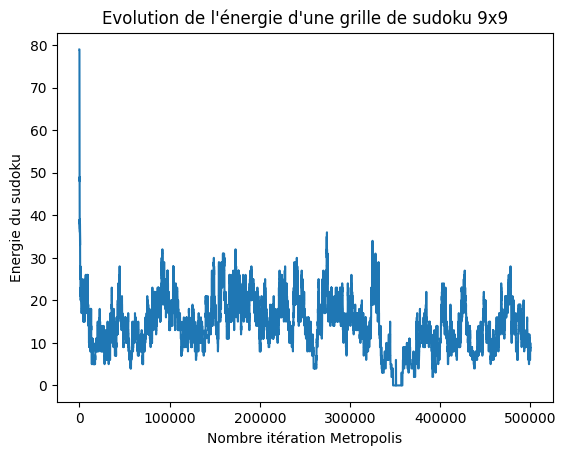

In [4]:
m9 = Metropolis(3**2)
m9.simulate(0.4, 500000)
m9.see_evolution()

## Analyse de transition de phase - Données C++

Chargement et visualisation des données de capacité thermique $C_T$ calculées avec le code C++.

In [10]:
def show_transition(filename, T_c = 0):

    # Charger les données depuis le fichier HDF5
    filename = '../../data/sudoku/' + filename

    with h5py.File(filename, 'r') as f:
        # Charger les métadonnées
        J = f['/metadata'].attrs['J']
        B = f['/metadata'].attrs['B']
        T_start = f['/metadata'].attrs['T_start']
        T_end = f['/metadata'].attrs['T_end']
        nb_inter_T = f['/metadata'].attrs['nb_inter_T']
        nb_metropolis_iteration = f['/metadata'].attrs['nb_metropolis_iteration']
        n = f['/metadata'].attrs['n']
        
        # Charger les données C_T
        C_T = f['/C_T'][:]

    # Créer le vecteur de températures
    temperatures = np.linspace(T_start, T_end, nb_inter_T)

    print(f"Données chargées:")
    print(f"  Grille: {n*n}x{n*n}")
    if J != 0 or B != 0:
        print(f"  J = {J}, B = {B}")
    print(f"  Températures: {T_start} à {T_end}")
    print(f"  Itérations Metropolis: {nb_metropolis_iteration}")
    print(f"  Nombre de points C_T: {len(C_T)}")

    # Trouver la température de transition (maximum de C_T) pour T > 0.25K
    # Calculer l'index de départ correspondant à T = 0.25
    T_min = 0.25
    start_idx = int((T_min - T_start) / (T_end - T_start) * nb_inter_T)
    start_idx = max(0, start_idx)  # S'assurer que l'index est >= 0
    
    # Trouver le max dans le sous-tableau et ajouter l'offset
    max_idx = start_idx + np.argmax(C_T[start_idx:])
    T_transition = temperatures[max_idx]
    C_T_max = C_T[max_idx]

    print(f"\nTempérature de transition: T_c ≈ {T_transition:.4f} K")
    print(f"Valeur maximale de C_T: {C_T_max:.4e}")

    # Tracer C_T en fonction de la température
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(temperatures, C_T, s=0.3, label='Data')
    ax.set_xlabel('Temperature T (K)', fontsize=12)
    ax.set_ylabel(r'Heat Capacity $C_T$', fontsize=12)
    #ax.set_title(f'Transition de phase - Sudoku {n*n}x{n*n}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')


    # Tracer la temperature de transition
    if T_c != 0:
        T_transition = T_c
    ax.axvline(T_transition, color='red', label=f'Transition Temperature : {T_transition:.2f} K')

    plt.tight_layout()
    plt.legend()
    plt.savefig(f'../../figures/sudoku/transition/{n*n}-transition.png')
    plt.show()

Données chargées:
  Grille: 4x4
  Températures: 0.0001 à 5.0
  Itérations Metropolis: 20000
  Nombre de points C_T: 8000

Température de transition: T_c ≈ 0.5483 K
Valeur maximale de C_T: 4.0115e+01


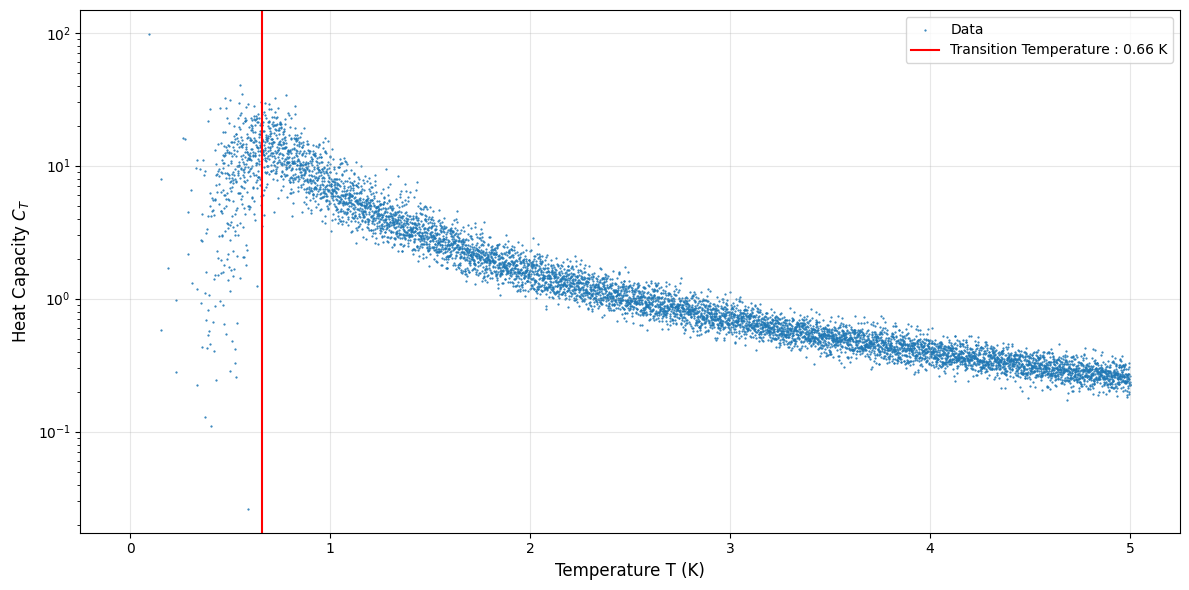

Données chargées:
  Grille: 9x9
  Températures: 0.0001 à 5.0
  Itérations Metropolis: 50000
  Nombre de points C_T: 8000

Température de transition: T_c ≈ 0.4376 K
Valeur maximale de C_T: 3.7581e+02


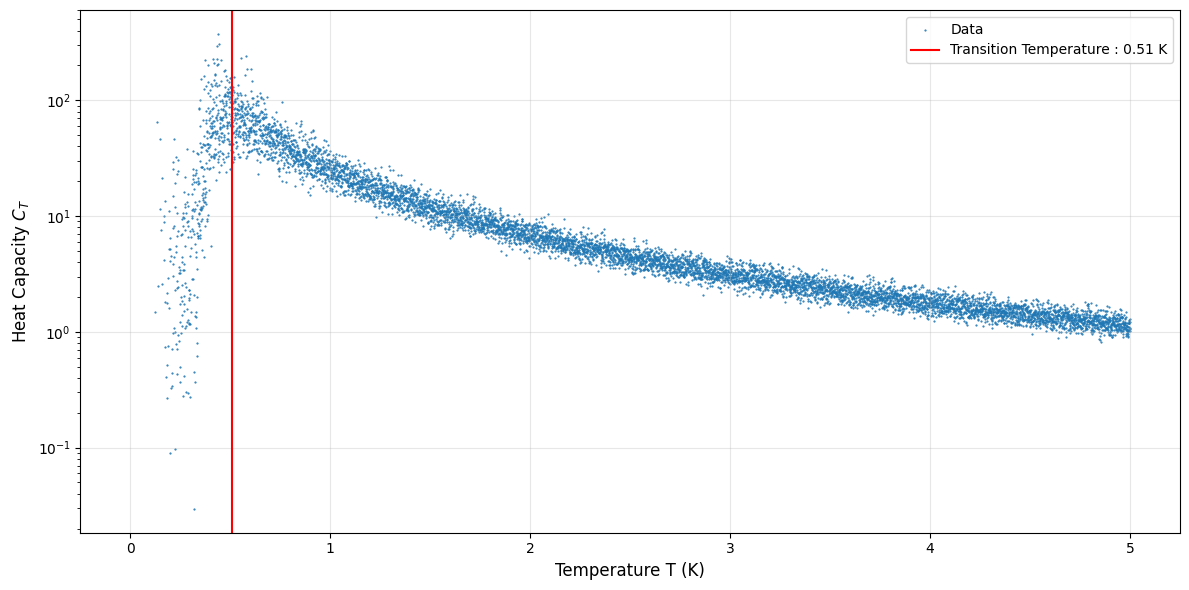

Données chargées:
  Grille: 16x16
  Températures: 0.0001 à 5.0
  Itérations Metropolis: 200000
  Nombre de points C_T: 8000

Température de transition: T_c ≈ 0.4745 K
Valeur maximale de C_T: 1.1904e+03


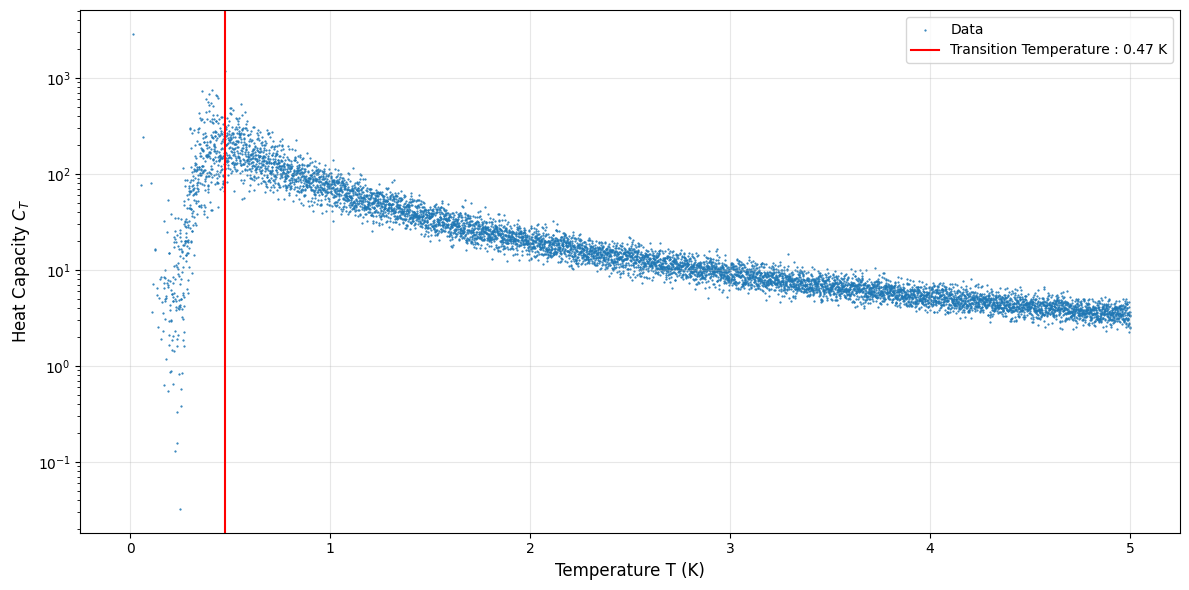

Données chargées:
  Grille: 25x25
  Températures: 0.0001 à 5.0
  Itérations Metropolis: 200000
  Nombre de points C_T: 8000

Température de transition: T_c ≈ 0.3695 K
Valeur maximale de C_T: 1.7647e+03


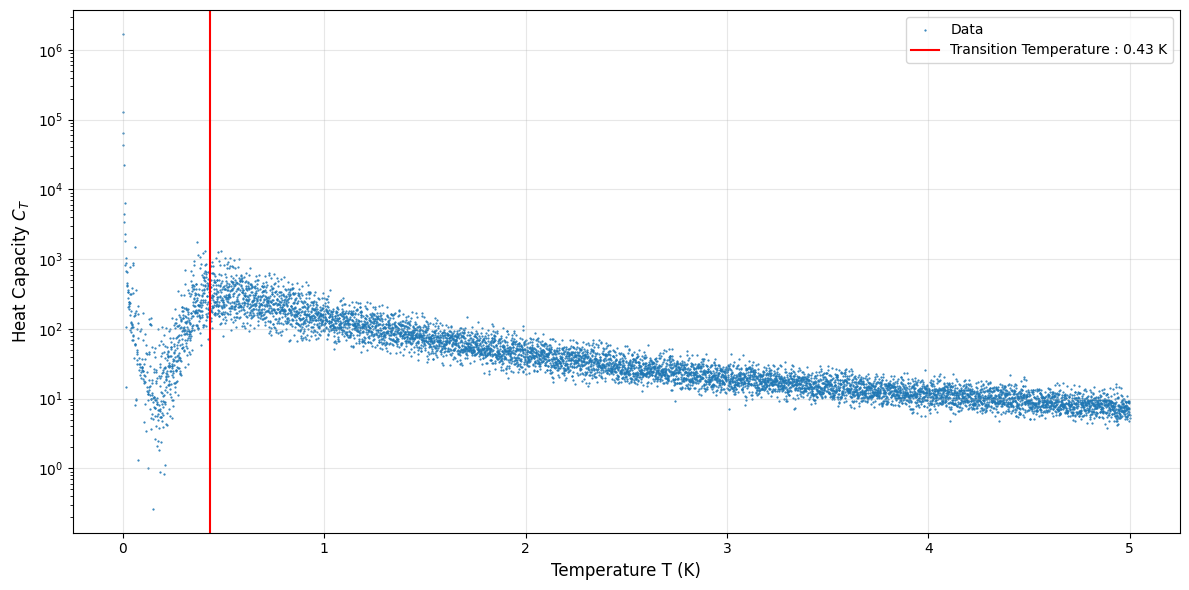

In [11]:
show_transition('4-transition.h5', T_c = 0.659)
show_transition('9-transition.h5', T_c = 0.51)
show_transition('16-transition.h5')
show_transition('25-transition.h5', T_c=0.43)

## Analyse de susceptibilité magnétik - Données C++

Chargement et visualisation des données de susceptibilité magnétik calculées avec le code C++.

In [ ]:
def show_sensibilite(filename, T_c, T_min=None):

    # Charger les données depuis le fichier HDF5
    filename = '../../data/sudoku/' + filename

    with h5py.File(filename, 'r') as f:
        # Charger les métadonnées
        J = f['/metadata'].attrs['J']
        B = f['/metadata'].attrs['B']
        T_start = f['/metadata'].attrs['T_start']
        T_end = f['/metadata'].attrs['T_end']
        nb_inter_T = f['/metadata'].attrs['nb_inter_T']
        nb_metropolis_iteration = f['/metadata'].attrs['nb_metropolis_iteration']
        n = f['/metadata'].attrs['n']
        
        # Charger les données C_T
        C_T = f['/C_T'][:]

    # Créer le vecteur de températures
    temperatures = np.linspace(T_start, T_end, nb_inter_T)
    
    # Par défaut T_min = T_start
    if T_min is None:
        T_min = T_start

    # Calculer l'index de départ correspondant à T_min
    start_idx = int((T_min - T_start) / (T_end - T_start) * nb_inter_T)
    start_idx = max(0, start_idx)  # S'assurer que l'index est >= 0

    print(f"Données chargées:")
    print(f"  Grille: {n*n}x{n*n}")
    if J != 0 or B != 0:
        print(f"  J = {J}, B = {B}")
    print(f"  Températures: {T_min} à {T_end}")
    print(f"  Itérations Metropolis: {nb_metropolis_iteration}")
    print(f"  Nombre de points Sensibilité: {len(C_T) - start_idx}")

    # Trouver la température de transition (maximum de C_T) pour T > T_min
    # Trouver le max dans le sous-tableau et ajouter l'offset
    max_idx = start_idx + np.argmax(C_T[start_idx:])
    T_transition = temperatures[max_idx]
    C_T_max = C_T[max_idx]

    print(f"\nTempérature de transition: T_c ≈ {T_transition:.4f} K")
    print(f"Valeur maximale de la sensibilité: {C_T_max:.4e}")

    # Tracer C_T en fonction de la température (seulement après T_min)
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(temperatures[start_idx:], C_T[start_idx:], s=0.3, label='Données')
    ax.set_xlabel('Température T (K)', fontsize=12)
    ax.set_ylabel(r'Sensibilité Magnétique', fontsize=12)
    #ax.set_title(f'Sensibilité Magnétique - Sudoku {n*n}x{n*n}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')


    # Tracer la temperature de transition
    ax.axvline(T_c, color='red', label=f'Température de Transition : {T_c} K')

    plt.tight_layout()
    plt.legend()
    plt.savefig(f'../../figures/sudoku/sensibility/{n*n}-sensibility.png')
    plt.show()

Données chargées:
  Grille: 9x9
  Températures: 1e-05 à 1.0
  Itérations Metropolis: 40000
  Nombre de points Sensibilité: 10000

Température de transition: T_c ≈ 0.0002 K
Valeur maximale de la sensibilité: 1.4163e+03


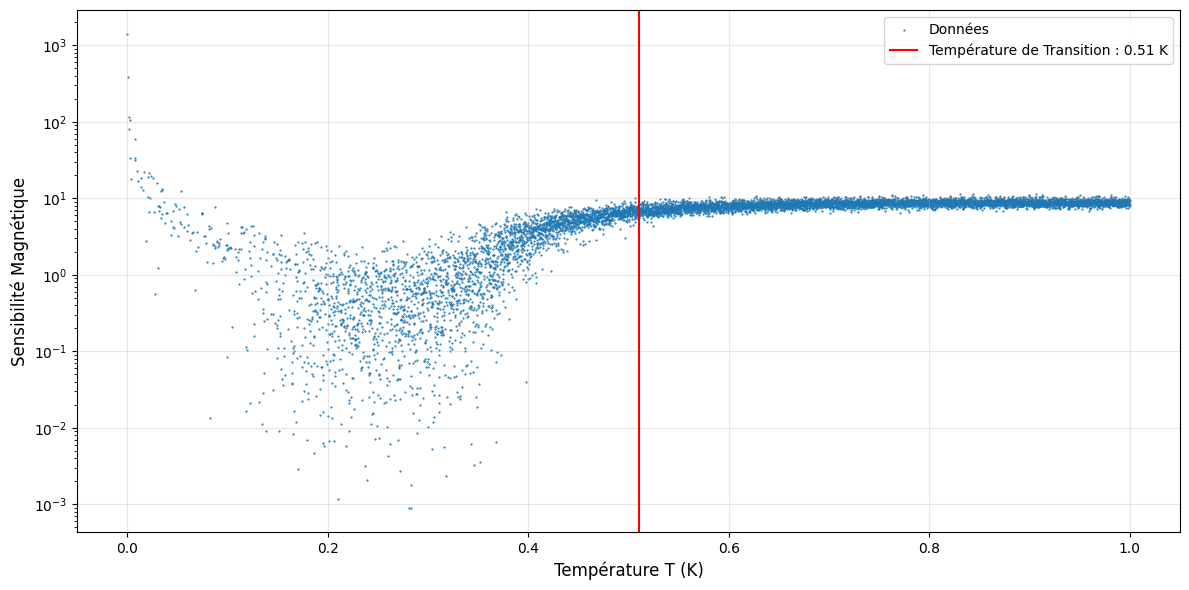

In [ ]:
show_sensibilite('9-magnetic.h5', 0.51)

Données chargées:
  Grille: 16x16
  Températures: 1e-05 à 1.0
  Itérations Metropolis: 40000
  Nombre de points Sensibilité: 10000

Température de transition: T_c ≈ 0.0000 K
Valeur maximale de la sensibilité: 4.6484e+04


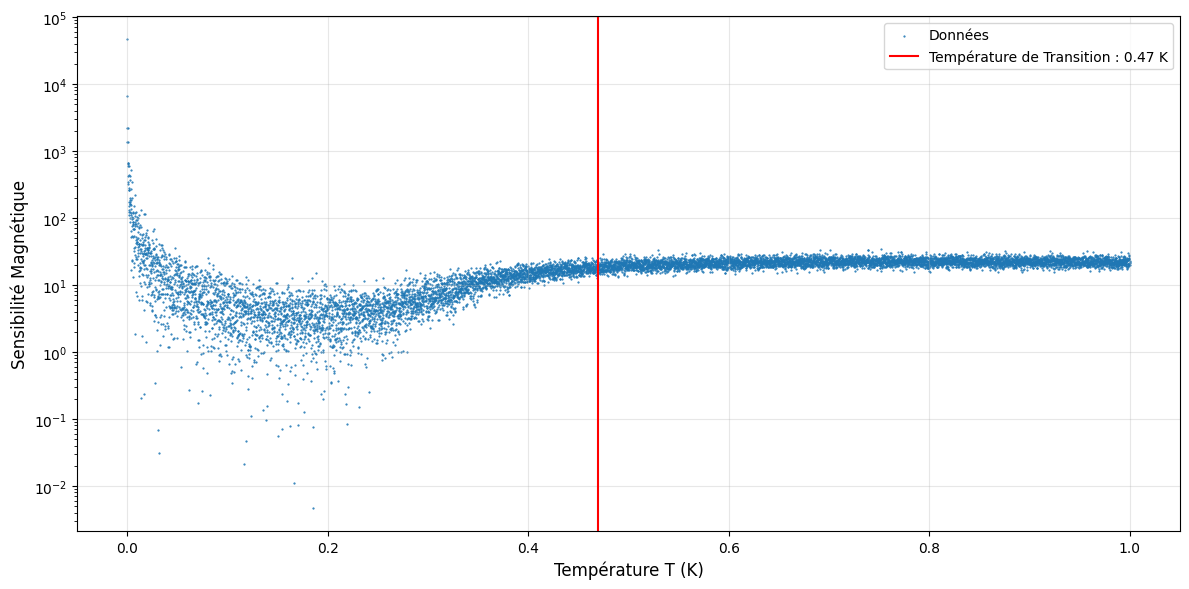

In [ ]:
show_sensibilite('16-magnetic.h5', 0.47)